# XDecomposer beginner tutorial: mix two patterns and run inference

This notebook shows how to: 
1. load two single-phase XRD patterns from `TestData_100`,
2. mix them into one synthetic multiphase pattern,
3. load the XDecomposer checkpoints,
4. run separation inference, and
5. visualize the predicted slots against the ground-truth weighted components.

> XDecomposer is trained to output **4 slots** by default, so even a 2-phase mixture will return 4 candidate sources. We use the activity scores plus correlation matching to identify the two most relevant slots for this demo.

If you do not already have the weights, download them from the project `Releases`


In [1]:
from pathlib import Path
import itertools
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from typing import Optional

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True


In [ ]:
def find_repo_root(start: Optional[Path] = None) -> Path:
    start = Path.cwd() if start is None else start
    for p in [start, *start.parents]:
        if (p / ".git").exists():
            return p
    raise FileNotFoundError("Repo root not found")


def first_existing(paths):
    for p in paths:
        if Path(p).exists():
            return Path(p)
    return None


def load_xy_pattern(csv_path: Path):
    df = pd.read_csv(csv_path)
    return df['angle'].to_numpy(np.float32), df['intensity'].to_numpy(np.float32)


def corrcoef_1d(a: np.ndarray, b: np.ndarray) -> float:
    a = a - a.mean()
    b = b - b.mean()
    denom = np.linalg.norm(a) * np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / denom)


def best_slot_assignment(preds: np.ndarray, targets: np.ndarray):
    best_slots = None
    best_score = -1e18
    for slots in itertools.permutations(range(preds.shape[0]), targets.shape[0]):
        score = sum(corrcoef_1d(preds[slot], targets[i]) for i, slot in enumerate(slots))
        if score > best_score:
            best_score = score
            best_slots = slots
    return list(best_slots), float(best_score)


repo_root = find_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.models.xrd_transformer import XRDMaskedAutoencoder
from src.models.xdecomposer import build_xdecomposer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('repo_root =', repo_root)
print('device =', device)


In [3]:
# --- Choose two single-phase examples from TestData_100 ---
pattern_ids = [31, 12]           # change these to try other examples
weights = np.array([0.65, 0.35], dtype=np.float32)
weights = weights / weights.sum()

angles = None
raw_patterns = []
for pid in pattern_ids:
    angle_i, intensity_i = load_xy_pattern(repo_root / 'tutorial/TestData_100' / f'{pid}_xy.csv')
    angles = angle_i if angles is None else angles
    raw_patterns.append(intensity_i)

weighted_targets = np.stack([p * w for p, w in zip(raw_patterns, weights)], axis=0)
mixture = weighted_targets.sum(axis=0)
scale = mixture.max() + 1e-8
mix_norm = mixture / scale
targets_norm = weighted_targets / scale

print('pattern_ids =', pattern_ids)
print('weights =', weights.tolist())
print('mix_norm shape =', mix_norm.shape)


pattern_ids = [31, 12]
weights = [0.6499999761581421, 0.3499999940395355]
mix_norm shape = (3500,)


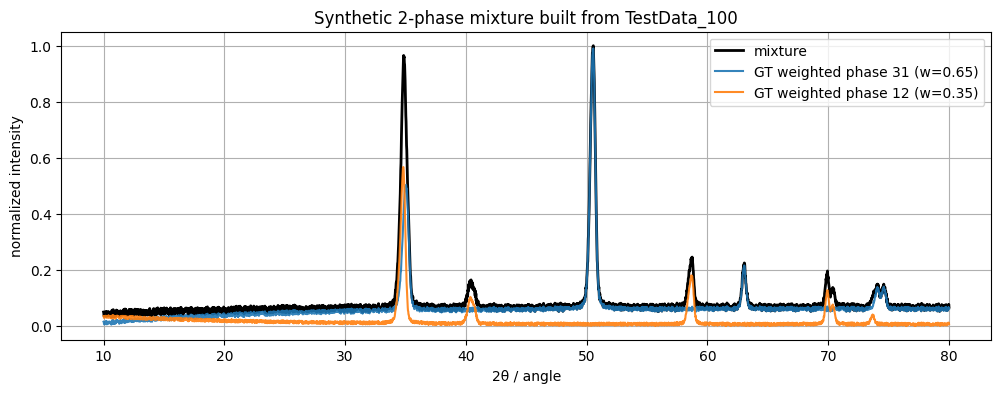

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(angles, mix_norm, label='mixture', lw=2, color='black')
for i, pid in enumerate(pattern_ids):
    ax.plot(angles, targets_norm[i], label=f'GT weighted phase {pid} (w={weights[i]:.2f})', alpha=0.9)
ax.set_title('Synthetic 2-phase mixture built from TestData_100')
ax.set_xlabel('2θ / angle')
ax.set_ylabel('normalized intensity')
ax.legend()
plt.show()


In [ ]:
# --- Resolve checkpoints ---
sep_candidates = [
    repo_root / 'checkpoints/separation/latest.pt',
    repo_root / 'checkpoints/sepration/latest.pt',
    repo_root / ' checkpoints/separation/latest.pt',
    repo_root / ' checkpoints/sepration/latest.pt',
]
mae_candidates = [
    repo_root / 'checkpoints/pretrain/checkpoint_latest.pt',
    repo_root / ' checkpoints/pretrain/checkpoint_latest.pt',
    repo_root / 'checkpoints/pretrain/best_model.pt',
    repo_root / ' checkpoints/pretrain/best_model.pt',
]

sep_path = first_existing(sep_candidates)
mae_path = first_existing(mae_candidates)
if sep_path is None or mae_path is None:
    raise FileNotFoundError(
        'Checkpoint(s) not found. Download/extract the weights from the Google Drive link in README.md.'
    )

print('separation checkpoint =', sep_path)
print('MAE checkpoint =', mae_path)

sep_ckpt = torch.load(sep_path, map_location='cpu')
mae_ckpt = torch.load(mae_path, map_location='cpu')
sep_conf = sep_ckpt['config']
mae_conf = mae_ckpt.get('config', {})

mae = XRDMaskedAutoencoder(
    xrd_length=sep_conf['xrd_length'],
    d_model=mae_conf.get('d_model', 768),
    n_layers=mae_conf.get('n_layers', 4),
    n_heads=mae_conf.get('n_heads', 12),
    decoder_d_model=mae_conf.get('decoder_dim', 512),
    decoder_n_layers=mae_conf.get('decoder_layers', 4),
)

model = build_xdecomposer(
    mae,
    num_sources=sep_conf['num_phases'],
    cnn_channels=sep_conf.get('cnn_channels', [64, 128, 256, 512]),
    cnn_kernels=sep_conf.get('cnn_kernels', None),
    cnn_strides=sep_conf.get('cnn_strides', None),
    use_transformer=not sep_conf.get('no_transformer', False),
    use_film=not sep_conf.get('no_film', False),
    use_skip_connections=not sep_conf.get('no_skip_connections', False),
    mask_type=sep_conf.get('mask_type', 'soft'),
)

state_dict = {
    (k[7:] if k.startswith('module.') else k): v
    for k, v in sep_ckpt['model_state_dict'].items()
}
model.load_state_dict(state_dict)
model = model.to(device).eval()

print('num_sources =', sep_conf['num_phases'])
print('xrd_length =', sep_conf['xrd_length'])


In [6]:
x = torch.tensor(mix_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
with torch.no_grad():
    preds, activity_logits = model(x)

preds_np = preds[0].detach().cpu().numpy()
activity_probs = torch.sigmoid(activity_logits)[0].detach().cpu().numpy()
matched_slots, match_score = best_slot_assignment(preds_np, targets_norm)
aligned_preds = preds_np[matched_slots]

print('preds shape =', preds_np.shape)
print('activity probs =', np.round(activity_probs, 4).tolist())
print('matched slots for the 2 GT phases =', matched_slots)
print('correlation match score =', round(match_score, 4))


preds shape = (4, 3500)
activity probs = [0.9470000267028809, 0.2655999958515167, 0.035599999129772186, 0.026000000536441803]
matched slots for the 2 GT phases = [0, 3]
correlation match score = 1.5436


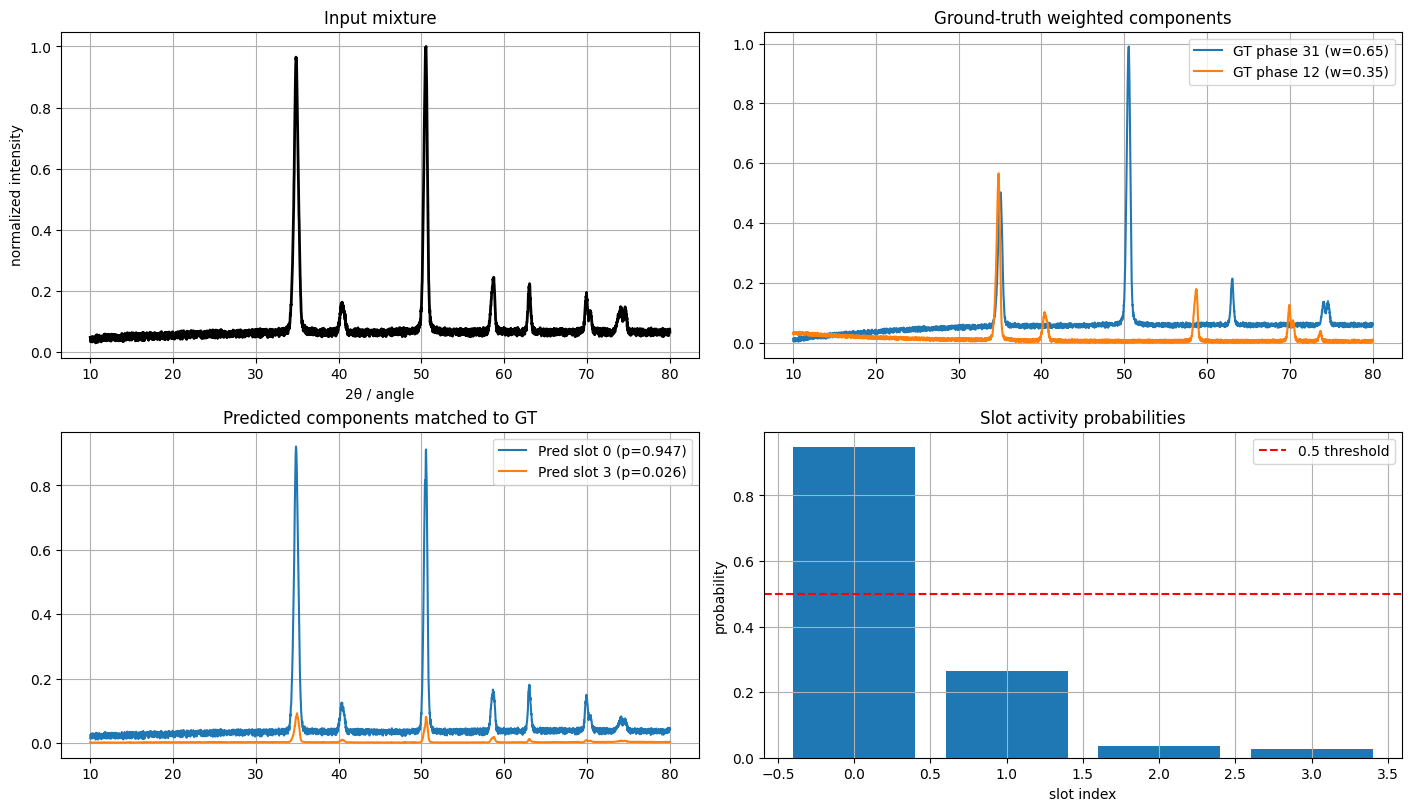

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

axes[0, 0].plot(angles, mix_norm, color='black', lw=2)
axes[0, 0].set_title('Input mixture')
axes[0, 0].set_xlabel('2θ / angle')
axes[0, 0].set_ylabel('normalized intensity')

for i, pid in enumerate(pattern_ids):
    axes[0, 1].plot(angles, targets_norm[i], label=f'GT phase {pid} (w={weights[i]:.2f})')
axes[0, 1].set_title('Ground-truth weighted components')
axes[0, 1].legend()

for i, slot in enumerate(matched_slots):
    axes[1, 0].plot(angles, aligned_preds[i], label=f'Pred slot {slot} (p={activity_probs[slot]:.3f})')
axes[1, 0].set_title('Predicted components matched to GT')
axes[1, 0].legend()

axes[1, 1].bar(np.arange(len(activity_probs)), activity_probs, color='tab:blue')
axes[1, 1].axhline(0.5, color='red', linestyle='--', label='0.5 threshold')
axes[1, 1].set_title('Slot activity probabilities')
axes[1, 1].set_xlabel('slot index')
axes[1, 1].set_ylabel('probability')
axes[1, 1].legend()

plt.show()


## Notes

- The training pipeline mixes raw single-phase patterns using random weights and then applies **max normalization** to the final mixture. This notebook follows the same idea for a simple two-pattern demo.
- The model was trained with `num_sources=4`, so inactive slots may still appear but should have low activity probabilities.
- To try other examples, only change `pattern_ids` and `weights` in the data cell above.
- For large-scale evaluation, use the project scripts under `scripts/bash_test/` and `scripts/python_runners/test_xdecomposer.py`.
